# HepGPU Demo: 3D Segmented Liver with Mini ParaView

This notebook reproduces the 3D segmented-liver case using a liver segmentation stored in `Segmentation_1.nrrd`.

It includes:
- package installation
- segmentation loading and preprocessing
- mask construction for vein and liver lobes
- HepGPU simulation
- VTK export
- an interactive mini ParaView viewer inside Google Colab using `pyvista` and `panel`

## Installation

In [5]:
!pip install git+https://github.com/navasmontilla/HepGPU.git
!pip install zarr numpy pyevtk SimpleITK scipy pyvista panel ipywidgets
!pip install jupyter_bokeh

  Cloning https://github.com/navasmontilla/HepGPU.git to /tmp/pip-req-build-qwv0dvik
  Running command git clone --filter=blob:none --quiet https://github.com/navasmontilla/HepGPU.git /tmp/pip-req-build-qwv0dvik
  Resolved https://github.com/navasmontilla/HepGPU.git to commit d4345888db13d8d6831f67dfc67097e1d03b3cc7
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Imports

In [6]:
import os
import io
import glob

import numpy as np
import zarr
import SimpleITK as sitk
import matplotlib.pyplot as plt
import pyvista as pv
import panel as pn

from scipy.ndimage import zoom
from ipywidgets import interact, IntSlider
from IPython.display import Image, display

from HepGPU.core import run
from HepGPU.zarr_utils import (
    export_zarr_to_vtk,
    export_zarr_to_png,
    export_zarr_to_2d_snapshot,
)

## Simulation grid

In [7]:
nx, ny, nz = 64, 64, 36
Lx, Ly, Lz = 1.0, 1.0, 1.0

tf = 5
td = 0.1
sigma = 0.15

## Load segmentation

In [8]:
segmentation_file = '/content/Segmentation_1.nrrd'

img = sitk.ReadImage(segmentation_file)
spacing = img.GetSpacing()
size_original = img.GetSize()

Lx_real = size_original[0] * spacing[0]
Ly_real = size_original[1] * spacing[1]
Lz_real = size_original[2] * spacing[2]

print("Real physical dimensions:")
print(f"Lx = {Lx_real:.2f} mm, Ly = {Ly_real:.2f} mm, Lz = {Lz_real:.2f} mm")

arr = sitk.GetArrayFromImage(img)
labels_zyx = arr

print("Segmentation shape:", labels_zyx.shape)
print("Segmentation dtype:", labels_zyx.dtype)
print("Unique labels:", np.unique(labels_zyx))

Real physical dimensions:
Lx = 462.00 mm, Ly = 462.00 mm, Lz = 710.00 mm
Segmentation shape: (284, 512, 512)
Segmentation dtype: int16
Unique labels: [ 0  1  5  6  7  8  9 10 11 12]


## Quick visualization of the segmentation

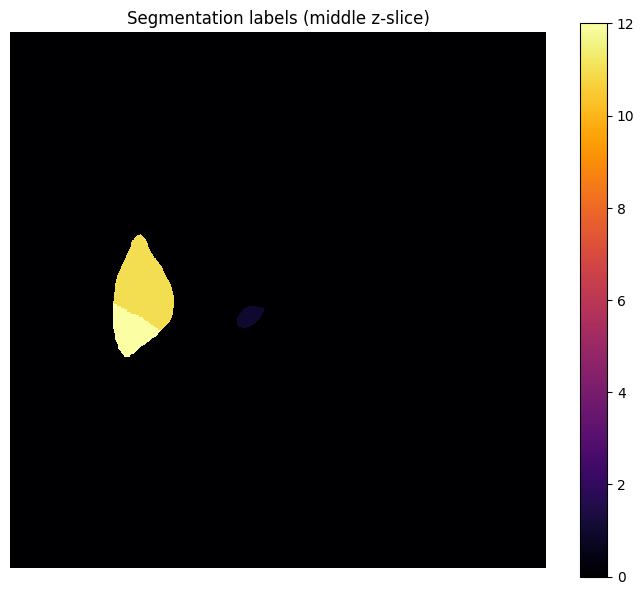

interactive(children=(IntSlider(value=142, description='z', max=283), Output()), _dom_classes=('widget-interac…

In [9]:
zmid = labels_zyx.shape[0] // 2

plt.figure(figsize=(7, 6))
plt.imshow(labels_zyx[zmid, :, :], cmap="inferno", interpolation="nearest")
plt.title("Segmentation labels (middle z-slice)")
plt.colorbar()
plt.axis("off")
plt.tight_layout()
plt.show()

def show_slice(z):
    plt.figure(figsize=(6, 6))
    plt.imshow(labels_zyx[z, :, :], cmap="inferno", interpolation="nearest")
    plt.title(f"Slice z = {z}")
    plt.colorbar()
    plt.axis("off")
    plt.show()

interact(show_slice, z=IntSlider(min=0, max=labels_zyx.shape[0]-1, step=1, value=zmid));

## Build masks from segmentation labels

In [10]:
ID_VEIN = 1
ID_LOBES = [5, 6, 7, 8, 9, 10, 11, 12]

mask_vein_zyx = (labels_zyx == ID_VEIN)

mask_left_lobe_2_zyx     = (labels_zyx == ID_LOBES[0])
mask_right_lobe_8_zyx    = (labels_zyx == ID_LOBES[1])
mask_central_lobe_4a_zyx = (labels_zyx == ID_LOBES[2])
mask_left_lobe_3_zyx     = (labels_zyx == ID_LOBES[3])
mask_central_lobe_4b_zyx = (labels_zyx == ID_LOBES[4])
mask_post_lobe_7_zyx     = (labels_zyx == ID_LOBES[5])
mask_right_lobe_5_zyx    = (labels_zyx == ID_LOBES[6])
mask_post_lobe_6_zyx     = (labels_zyx == ID_LOBES[7])

lobes_zyx = [
    mask_left_lobe_2_zyx,
    mask_right_lobe_8_zyx,
    mask_central_lobe_4a_zyx,
    mask_left_lobe_3_zyx,
    mask_central_lobe_4b_zyx,
    mask_post_lobe_7_zyx,
    mask_right_lobe_5_zyx,
    mask_post_lobe_6_zyx,
]

mask_liver_zyx = np.logical_or.reduce(lobes_zyx)

print("Background voxels:", (labels_zyx == 0).sum())
print("Vein voxels:", mask_vein_zyx.sum())
print("Liver voxels:", mask_liver_zyx.sum())
print("Lobe voxels:", [m.sum() for m in lobes_zyx])

Background voxels: 73377779
Vein voxels: 91749
Liver voxels: 979368
Lobe voxels: [np.int64(102361), np.int64(212220), np.int64(100933), np.int64(72279), np.int64(111049), np.int64(143708), np.int64(196667), np.int64(40151)]


## Convert masks to (x, y, z) and resample to the simulation grid

In [11]:
mask_vein = np.transpose(mask_vein_zyx, (2, 1, 0))

mask_left_lobe_2     = np.transpose(mask_left_lobe_2_zyx,     (2, 1, 0))
mask_right_lobe_8    = np.transpose(mask_right_lobe_8_zyx,    (2, 1, 0))
mask_central_lobe_4a = np.transpose(mask_central_lobe_4a_zyx, (2, 1, 0))
mask_left_lobe_3     = np.transpose(mask_left_lobe_3_zyx,     (2, 1, 0))
mask_central_lobe_4b = np.transpose(mask_central_lobe_4b_zyx, (2, 1, 0))
mask_post_lobe_7     = np.transpose(mask_post_lobe_7_zyx,     (2, 1, 0))
mask_right_lobe_5    = np.transpose(mask_right_lobe_5_zyx,    (2, 1, 0))
mask_post_lobe_6     = np.transpose(mask_post_lobe_6_zyx,     (2, 1, 0))

sx, sy, sz = mask_vein.shape
zx, zy, zz = nx / sx, ny / sy, nz / sz

def resample_mask(mask):
    return zoom(mask.astype(np.uint8), (zx, zy, zz), order=0).astype(bool)

mask_vein = resample_mask(mask_vein)

mask_left_lobe_2     = resample_mask(mask_left_lobe_2)
mask_right_lobe_8    = resample_mask(mask_right_lobe_8)
mask_central_lobe_4a = resample_mask(mask_central_lobe_4a)
mask_left_lobe_3     = resample_mask(mask_left_lobe_3)
mask_central_lobe_4b = resample_mask(mask_central_lobe_4b)
mask_post_lobe_7     = resample_mask(mask_post_lobe_7)
mask_right_lobe_5    = resample_mask(mask_right_lobe_5)
mask_post_lobe_6     = resample_mask(mask_post_lobe_6)

## Resolve overlaps and build the simulation masks

In [12]:
lobes = [
    mask_left_lobe_2,
    mask_right_lobe_8,
    mask_central_lobe_4a,
    mask_left_lobe_3,
    mask_central_lobe_4b,
    mask_post_lobe_7,
    mask_right_lobe_5,
    mask_post_lobe_6,
]

lobes = [m & (~mask_vein) for m in lobes]

occupied = mask_vein.copy()
lobes_clean = []

for m in lobes:
    mc = m & (~occupied)
    lobes_clean.append(mc)
    occupied |= mc

(
    mask_left_lobe_2,
    mask_right_lobe_8,
    mask_central_lobe_4a,
    mask_left_lobe_3,
    mask_central_lobe_4b,
    mask_post_lobe_7,
    mask_right_lobe_5,
    mask_post_lobe_6,
) = lobes_clean

mask_liver = np.logical_or.reduce(lobes_clean)
mask_background = ~occupied

print("Background voxels:", mask_background.sum())
print("Vein voxels:", mask_vein.sum())
print("Liver voxels:", mask_liver.sum())

cover = mask_background.sum() + mask_vein.sum() + sum(m.sum() for m in lobes_clean)
print("Do masks cover the full grid?", cover == nx * ny * nz)

Background voxels: 145461
Vein voxels: 156
Liver voxels: 1839
Do masks cover the full grid? True


## HepGPU masks and parameters

In [13]:
background_values = (0.0, 0.0, 0.0, 0.0)

masks = [
    (mask_background, background_values),

    # (d1, dTh, dTc, d3)
    (mask_left_lobe_2,     (0.006, 0.08, 0.05, 0.04)),
    (mask_right_lobe_8,    (0.008, 0.09, 0.07, 0.05)),
    (mask_central_lobe_4a, (0.007, 0.085, 0.06, 0.045)),
    (mask_left_lobe_3,     (0.006, 0.08, 0.05, 0.04)),
    (mask_central_lobe_4b, (0.007, 0.085, 0.06, 0.045)),
    (mask_post_lobe_7,     (0.008, 0.09, 0.07, 0.05)),
    (mask_right_lobe_5,    (0.008, 0.09, 0.07, 0.05)),
    (mask_post_lobe_6,     (0.008, 0.09, 0.07, 0.05)),
]

params = {
    "a1": 1.0,
    "C1": 1.0,
    "epsilon": 0.05,
    "kappa": 0.05,

    "a5": 0.036,

    "a2h": 14.0,
    "Cth": 8.0,
    "a6h": 0.2,

    "a2c": 8.0,
    "Ctc": 15.0,
    "a6c": 0.03,

    "a3": 0.6,
    "a_nd": 1.0,
}

out_name = "output_3d_liver_segmented_elimination.zarr"
results_dir = "results_3d_liver_segmented_elimination"

## Run simulation

In [ ]:
run(
    use_gpu=True,
    Lx=Lx,
    Ly=Ly,
    Lz=Lz,

    nx=nx,
    ny=ny,
    nz=nz,

    tf=tf,
    td=td,

    sigma=sigma,
    params=params,
    mask_inflow=mask_vein,
    CI_values=(0.1, 0.0, 0.0, 0.0),
    masks=masks,
    out_name=out_name,
)

print("Simulation finished.")

Grid: 64x64x36, dt=4.19921e-05, nt=119070, device=GPU
Saving every  2381 steps (simulated ≈ 0.1 s)
Integral of xi = 0.9999999999999111
Count: 156


## Store geometry in Zarr

In [ ]:
store = zarr.open(out_name, mode="a")
store.attrs["tf"] = tf
store.attrs["td"] = td

lobes_field = np.zeros((nx, ny, nz), dtype=np.float32)

lobes_field[mask_left_lobe_2] = 2
lobes_field[mask_right_lobe_8] = 8
lobes_field[mask_central_lobe_4a] = 41
lobes_field[mask_left_lobe_3] = 3
lobes_field[mask_central_lobe_4b] = 42
lobes_field[mask_post_lobe_7] = 7
lobes_field[mask_right_lobe_5] = 5
lobes_field[mask_post_lobe_6] = 6

if "geometry" in store:
    del store["geometry"]

geometry_grp = store.create_group("geometry")

geometry_grp.create(
    "xi",
    data=mask_vein.astype(np.float32),
    chunks=(nx, ny, nz)
)

geometry_grp.create(
    "liver",
    data=mask_liver.astype(np.float32),
    chunks=(nx, ny, nz)
)

geometry_grp.create(
    "lobes",
    data=lobes_field.astype(np.float32),
    chunks=(nx, ny, nz)
)

print("Geometry fields:", list(geometry_grp.keys()))

## Export results

In [ ]:
export_zarr_to_vtk(
    zarr_file=out_name,
    output_dir=os.path.join(results_dir, "vtk"),
    geom_group="geometry",
    export_coefficients=True,
)

export_zarr_to_png(
    zarr_file=out_name,
    output_dir=os.path.join(results_dir, "plots"),
    mask_domain=mask_domain,
)

export_zarr_to_2d_snapshot(
    zarr_file=out_name,
    output_path=os.path.join(
        results_dir,
        "plots",
        "spatial_snapshot_step100.png"
    ),
    step=100,
)

print("Export completed.")

## Display one 2D snapshot

In [ ]:
img_path = os.path.join(results_dir, "spatial_snapshot_step_0.png")
if os.path.exists(img_path):
    display(Image(filename=img_path))
else:
    print("Snapshot image not found.")

## Mini ParaView (Colab image version)

In [ ]:
pn.extension()
pv.OFF_SCREEN = True

files = sorted(glob.glob(os.path.join(results_dir, "vtk", "*.vti")))
if len(files) == 0:
    raise ValueError("No .vti files found in the VTK output folder.")

grid0 = pv.read(files[0])
scalars_list = grid0.array_names

# ---------------------------------
# Widgets
# ---------------------------------
time_slider = pn.widgets.IntSlider(name="Time Step", start=0, end=len(files)-1, value=0)

scalar_select = pn.widgets.Select(name="Variable", options=scalars_list, value=scalars_list[0])

cmap_select = pn.widgets.Select(
    name="Colormap",
    options=["viridis", "plasma", "coolwarm", "inferno"],
    value="viridis"
)

mode_select = pn.widgets.Select(
    name="View Mode",
    options=["surface", "slice", "contour", "threshold"],
    value="surface"
)

view_select = pn.widgets.Select(
    name="Camera View",
    options=["isometric", "xy", "xz", "yz"],
    value="isometric"
)

show_box_checkbox = pn.widgets.Checkbox(name="Show Box", value=True)

n_contours_slider = pn.widgets.IntSlider(name="N Contours", start=1, end=10, value=5)

slice_x_slider = pn.widgets.FloatSlider(name="Slice X", start=0, end=1, step=0.01, value=0.5)
slice_y_slider = pn.widgets.FloatSlider(name="Slice Y", start=0, end=1, step=0.01, value=0.5)
slice_z_slider = pn.widgets.FloatSlider(name="Slice Z", start=0, end=1, step=0.01, value=0.5)

# transparencia
opacity_slider = pn.widgets.FloatSlider(
    name="Opacity",
    start=0.05,
    end=1.0,
    step=0.05,
    value=1.0
)

# threshold
threshold_slider = pn.widgets.FloatSlider(
    name="Threshold (min)",
    start=0.0,
    end=1.0,
    step=0.01,
    value=0.1
)

# ---------------------------------
# Render
# ---------------------------------
def render_image(time_step, scalar, cmap, mode, view, show_box,
                 n_contours, sx, sy, sz, opacity, threshold_val):

    grid = pv.read(files[time_step])
    plotter = pv.Plotter(off_screen=True, window_size=(800, 500))

    xmin, xmax, ymin, ymax, zmin, zmax = grid.bounds
    x0 = xmin + sx * (xmax - xmin)
    y0 = ymin + sy * (ymax - ymin)
    z0 = zmin + sz * (zmax - zmin)

    # ---------------------------------
    # MODOS
    # ---------------------------------
    if mode == "surface":
        plotter.add_mesh(grid, scalars=scalar, cmap=cmap, opacity=opacity)

    elif mode == "slice":
        sliced = grid.slice_orthogonal(x=x0, y=y0, z=z0)
        plotter.add_mesh(sliced, scalars=scalar, cmap=cmap, opacity=opacity)

    elif mode == "contour":
        try:
            contour = grid.contour(isosurfaces=n_contours, scalars=scalar)
            plotter.add_mesh(contour, scalars=scalar, cmap=cmap, opacity=opacity)
        except Exception as e:
            plotter.add_text(f"Contour failed: {e}", font_size=10)

    # threshold
    elif mode == "threshold":
        try:
            th = grid.threshold(value=threshold_val, scalars=scalar)
            plotter.add_mesh(th, scalars=scalar, cmap=cmap, opacity=opacity)
        except Exception as e:
            plotter.add_text(f"Threshold failed: {e}", font_size=10)

    # ---------------------------------
    if show_box:
        plotter.add_mesh(grid.outline(), color="white", line_width=2)

    if view == "xy":
        plotter.view_xy()
    elif view == "xz":
        plotter.view_xz()
    elif view == "yz":
        plotter.view_yz()
    else:
        plotter.view_isometric()

    plotter.reset_camera()

    img = plotter.screenshot(return_img=True)
    plotter.close()

    buf = io.BytesIO()
    plt.imsave(buf, img)
    buf.seek(0)

    return pn.pane.PNG(buf.getvalue(), sizing_mode="stretch_width")

# ---------------------------------
# Binding
# ---------------------------------
viewer = pn.bind(
    render_image,
    time_slider,
    scalar_select,
    cmap_select,
    mode_select,
    view_select,
    show_box_checkbox,
    n_contours_slider,
    slice_x_slider,
    slice_y_slider,
    slice_z_slider,
    opacity_slider,
    threshold_slider
)

# ---------------------------------
# Layout
# ---------------------------------
dashboard = pn.Column(
    "# Mini ParaView",
    pn.Row(time_slider),
    pn.Row(scalar_select, cmap_select),
    pn.Row(mode_select, view_select),
    pn.Row(show_box_checkbox, n_contours_slider),
    pn.Row(opacity_slider, threshold_slider),
    pn.Row(slice_x_slider, slice_y_slider, slice_z_slider),
    viewer,
)

dashboard